# CV Analysis System — XGBoost Model
**Tasks:** Profile Matching · ATS Scoring · Section Scoring
**Datasets:**
- `cnamuangtoun/resume-job-description-fit` → Profile Matching + Section Scoring (synthetic)
- `0xnbk/resume-ats-score-v1-en` → ATS Scoring

## 1. Installation & Imports

In [ ]:
!pip install -q sentence-transformers datasets xgboost scikit-learn imbalanced-learn \
    matplotlib seaborn tabulate numpy pandas joblib optuna

import os, re, json, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import torch
import optuna
from tabulate import tabulate
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
)
from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 12.9 MB/s eta 0:00:00


## 2. Config

In [ ]:
SEED = 42
np.random.seed(SEED)
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

@dataclass
class Config:
    test_size:                  float = 0.20
    match_confidence_threshold: float = 0.60
    grade_excellent:            int   = 80
    grade_good:                 int   = 60
    grade_fair:                 int   = 40
    weight_section_overall:     float = 0.60
    weight_ats:                 float = 0.40
    optuna_trials:              int   = 20
    pca_components:             int   = 128
    section_keywords:           dict  = None
    cliches:                    list  = None

    def __post_init__(self):
        if self.section_keywords is None:
            self.section_keywords = {
                "has_summary":    ["summary", "profile", "about", "objective"],
                "has_skills":     ["skills", "expertise", "competencies", "technical"],
                "has_experience": ["experience", "employment", "work history"],
                "has_education":  ["education", "academic", "qualification", "degree"],
            }
        if self.cliches is None:
            self.cliches = [
                "team player", "hard-working", "go-getter", "self-starter",
                "detail-oriented", "results-oriented", "passionate about",
            ]

CFG = Config()
MATCH_LABEL_MAP = {0: "No Fit", 1: "Potential Fit", 2: "Good Fit"}
TARGET_COLS     = ["score_experience", "score_skills", "score_education", "score_overall"]

print(f"Device         : {DEVICE}")
print(f"Models         : {MODEL_DIR.resolve()}")
print(f"test_size      : {CFG.test_size}")
print(f"optuna_trials  : {CFG.optuna_trials}")
print(f"pca_components : {CFG.pca_components}")

Device         : cuda
Models         : /content/models
test_size      : 0.2
optuna_trials  : 20
pca_components : 128


## 3. Nomic Embed Encoder

In [ ]:
encoder = SentenceTransformer(
    "nomic-ai/nomic-embed-text-v1", trust_remote_code=True, device=DEVICE
)

def encode_texts(texts: List[str], batch_size: int = 32,
                 prefix: str = "search_document") -> np.ndarray:
    prefixed = [f"{prefix}: {t}" for t in texts]
    return encoder.encode(
        prefixed, batch_size=batch_size, show_progress_bar=True,
        normalize_embeddings=True, convert_to_numpy=True,
    )

def build_pair_features(emb_a: np.ndarray, emb_b: np.ndarray) -> np.ndarray:
    cos  = (emb_a * emb_b).sum(axis=1, keepdims=True)
    diff = np.abs(emb_a - emb_b)
    prod = emb_a * emb_b
    return np.hstack([cos, diff, prod])

print("Encoder loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/71.3k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.03k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

Encoder loaded.


## 4. ATS Feature Extractor

In [ ]:
def extract_ats_features(text: str) -> Dict[str, float]:
    t     = text.lower()
    words = text.split()
    wc    = len(words)
    feats = {}
    for key, kws in CFG.section_keywords.items():
        feats[key] = int(any(k in t for k in kws))
    feats["has_email"]    = int(bool(re.search(r"[\w.+-]+@[\w-]+\.[a-z]{2,}", text)))
    feats["has_phone"]    = int(bool(re.search(r"\+?\d[\d\s\-\.\(\)]{6,}\d", text)))
    feats["has_dates"]    = int(bool(re.search(r"\b(19|20)\d{2}\b", text)))
    feats["has_metrics"]  = int(bool(re.search(
        r"\d+\s*(%|percent|users|clients|revenue|saving|increase|decrease)", t)))
    feats["has_bullets"]  = int(bool(re.search(r"^[•\-\*]", text, re.MULTILINE)))
    feats["no_cliches"]   = int(not any(c in t for c in CFG.cliches))
    feats["word_count"]   = wc
    feats["wc_optimal"]   = int(300 <= wc <= 800)
    feats["wc_too_short"] = int(wc < 200)
    feats["wc_too_long"]  = int(wc > 1200)
    feats["unique_ratio"] = len(set(words)) / max(wc, 1)
    feats["avg_word_len"] = float(np.mean([len(w) for w in words])) if words else 0.0
    return feats

## 5. Dataset 1 — Profile Matching

In [ ]:
ds_match = load_dataset("cnamuangtoun/resume-job-description-fit")
df_match  = pd.concat([
    ds_match["train"].to_pandas(),
    ds_match["test"].to_pandas(),
]).reset_index(drop=True)

df_match = df_match.dropna(subset=["resume_text", "job_description_text", "label"])
df_match["resume_text"]          = df_match["resume_text"].str.strip()
df_match["job_description_text"] = df_match["job_description_text"].str.strip()
df_match["label"]                = df_match["label"].str.strip().str.title()

# Binary classification: Fit vs No Fit
label_map = {"Good Fit": 1, "Potential Fit": 1, "No Fit": 0}
df_match["label_enc"] = df_match["label"].map(label_map)
df_match = df_match.dropna(subset=["label_enc"]).reset_index(drop=True)
df_match["label_enc"] = df_match["label_enc"].astype(int)

MATCH_LABEL_MAP = {0: "No Fit", 1: "Fit"}

print("=" * 55)
print("  DATASET — cnamuangtoun/resume-job-description-fit")
print("=" * 55)
print(f"  Total rows : {len(df_match)}")
print(f"  Task       : Binary classification (Fit vs No Fit)")
print(f"  Label dist :")
binary_dist = df_match["label_enc"].value_counts().sort_index()
for k, v in binary_dist.items():
    print(f"    {MATCH_LABEL_MAP[k]:<10}: {v}")
print()
print("  Original label breakdown:")
print(df_match["label"].value_counts().to_string())
print()
print("  Sample (first 2 rows):")
print(df_match[["resume_text", "job_description_text", "label"]].head(2).to_string())

train.csv:   0%|          | 0.00/53.4M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

  DATASET — cnamuangtoun/resume-job-description-fit
  Total rows : 8000
  Task       : Binary classification (Fit vs No Fit)
  Label dist :
    No Fit    : 4000
    Fit       : 4000

  Original label breakdown:
label
No Fit           4000
Potential Fit    2000
Good Fit         2000

  Sample (first 2 rows):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

## 6. Dataset 2 — ATS Scoring

In [ ]:
ds_ats = load_dataset("0xnbk/resume-ats-score-v1-en")
df_ats = ds_ats["train"].to_pandas().dropna(subset=["text", "ats_score"])

def split_sep(text: str) -> Tuple[str, str]:
    parts = str(text).split(" SEP ", 1)
    return (parts[0].strip(), parts[1].strip()) if len(parts) == 2 else (parts[0].strip(), "")

df_ats[["resume", "job"]] = df_ats["text"].apply(lambda x: pd.Series(split_sep(x)))
df_ats["ats_score"]       = pd.to_numeric(df_ats["ats_score"], errors="coerce")
df_ats = df_ats.dropna(subset=["ats_score"])
df_ats = df_ats[df_ats["resume"].str.len() > 50].reset_index(drop=True)

print("=" * 55)
print("  DATASET — 0xnbk/resume-ats-score-v1-en")
print("=" * 55)
print(f"  Total rows : {len(df_ats)}")
print(f"  ATS score  : mean={df_ats['ats_score'].mean():.2f} | "
      f"std={df_ats['ats_score'].std():.2f} | "
      f"min={df_ats['ats_score'].min():.1f} | max={df_ats['ats_score'].max():.1f}")
print()
print("  Sample (first 2 rows):")
print(df_ats[["resume", "ats_score"]].head(2).to_string())

README.md:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/43.3M [00:00<?, ?B/s]

validation.csv:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5099 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1275 [00:00<?, ? examples/s]

  DATASET — 0xnbk/resume-ats-score-v1-en
  Total rows : 5098
  ATS score  : mean=47.19 | std=24.97 | min=19.2 | max=90.0

  Sample (first 2 rows):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

## 7. Generate Synthetic Section Scores

In [ ]:
def extract_section(text: str, keywords: List[str]) -> str:
    text_lower = text.lower()
    for kw in keywords:
        idx = text_lower.find(kw)
        if idx != -1:
            return text[idx:idx + 500].strip()
    return text[:300].strip()

SECTION_DEFS = {
    "experience": ["experience", "work experience", "employment history"],
    "skills":     ["skills", "technical skills", "expertise", "competencies"],
    "education":  ["education", "academic", "qualification", "degree"],
}

records = []
for _, row in df_match.iterrows():
    record = {"resume": row["resume_text"], "jd": row["job_description_text"]}
    for section, kws in SECTION_DEFS.items():
        record[f"section_{section}"] = extract_section(row["resume_text"], kws)
    records.append(record)

df_section_raw = pd.DataFrame(records)

print("=" * 55)
print("  SECTION SCORING — Synthetic from Match Dataset")
print("=" * 55)
print(f"  Total rows : {len(df_section_raw)}")
print(f"  Method     : cosine similarity per section vs JD")
print()
print("  Sample sections (row 0):")
for sec in SECTION_DEFS.keys():
    preview = df_section_raw[f"section_{sec}"].iloc[0][:80].replace("\n", " ")
    print(f"  [{sec}] {preview}...")

  SECTION SCORING — Synthetic from Match Dataset
  Total rows : 8000
  Method     : cosine similarity per section vs JD

  Sample sections (row 0):
  [experience] experience. Outgoing sales professional with track record of driving increased s...
  [skills] Skills: Public Speaking, Public Relations, Team Building, Project Management, Pr...
  [education] EducationMaster of Arts:Christian Education,Expected in-Dallas Theological Semin...


## 8. Encode Datasets + PCA

In [ ]:
# Profile matching embeddings
emb_resume = encode_texts(df_match["resume_text"].tolist())
emb_job    = encode_texts(df_match["job_description_text"].tolist(), prefix="search_query")
y_match    = df_match["label_enc"].values

# ATS features (rule-based)
feat_df           = df_ats["resume"].apply(lambda x: pd.Series(extract_ats_features(x)))
X_ats             = feat_df.values
y_ats = df_ats["ats_score"].values
feature_names_ats = feat_df.columns.tolist()

# Section scoring
emb_jd_sec = encode_texts(df_section_raw["jd"].tolist(), prefix="search_query")
emb_full   = encode_texts(df_section_raw["resume"].tolist())

section_scores = []
for section in ["experience", "skills", "education"]:
    emb_sec  = encode_texts(
        df_section_raw[f"section_{section}"].tolist(), prefix="search_document"
    )
    cos      = (emb_sec * emb_jd_sec).sum(axis=1)
    cos_norm = (cos - cos.min()) / (cos.max() - cos.min() + 1e-8)
    section_scores.append(cos_norm)

cos_overall      = (emb_full * emb_jd_sec).sum(axis=1)
cos_overall_norm = (cos_overall - cos_overall.min()) /                    (cos_overall.max() - cos_overall.min() + 1e-8)
section_scores.append(cos_overall_norm)
y_section = np.column_stack(section_scores)

# Explicit features for match and section (augment embeddings)
def extract_explicit_features(resume: str, jd: str) -> np.ndarray:
    r_lower = resume.lower()
    j_lower = jd.lower()
    r_words = set(r_lower.split())
    j_words = set(j_lower.split())
    overlap       = len(r_words & j_words) / max(len(j_words), 1)
    len_ratio     = min(len(resume), len(jd)) / max(max(len(resume), len(jd)), 1)
    has_email     = int(bool(re.search(r"[\w.+-]+@[\w-]+\.[a-z]{2,}", resume)))
    has_phone     = int(bool(re.search(r"\+?\d[\d\s\-\.\(\)]{6,}\d", resume)))
    has_dates     = int(bool(re.search(r"\b(19|20)\d{2}\b", resume)))
    has_skills_kw = int(any(k in r_lower for k in ["skills", "expertise", "proficient"]))
    has_exp_kw    = int(any(k in r_lower for k in ["experience", "worked", "developed"]))
    has_edu_kw    = int(any(k in r_lower for k in ["education", "degree", "university"]))
    has_metrics   = int(bool(re.search(
        r"\d+\s*(%|percent|users|clients|revenue|saving|increase|decrease)", r_lower)))
    r_word_count  = min(len(resume.split()) / 1000, 1.0)
    return np.array([overlap, len_ratio, has_email, has_phone, has_dates,
                     has_skills_kw, has_exp_kw, has_edu_kw, has_metrics, r_word_count])

extra_match = np.vstack([
    extract_explicit_features(r, j)
    for r, j in zip(df_match["resume_text"], df_match["job_description_text"])
])
extra_section = np.vstack([
    extract_explicit_features(r, j)
    for r, j in zip(df_section_raw["resume"], df_section_raw["jd"])
])

# PCA + concat explicit features
X_match_raw  = build_pair_features(emb_resume, emb_job)
pca_match    = PCA(n_components=CFG.pca_components, random_state=SEED)
X_match      = np.hstack([pca_match.fit_transform(X_match_raw), extra_match])

X_section_raw = build_pair_features(emb_full, emb_jd_sec)
pca_section   = PCA(n_components=CFG.pca_components, random_state=SEED)
X_section     = np.hstack([pca_section.fit_transform(X_section_raw), extra_section])

print(f"Match   : {X_match_raw.shape} → PCA {CFG.pca_components}d + 10 explicit = {X_match.shape}")
print(f"ATS     : {X_ats.shape}")
print(f"Section : {X_section_raw.shape} → PCA {CFG.pca_components}d + 10 explicit = {X_section.shape}")
print()
print("Section score distribution:")
print(pd.DataFrame(y_section, columns=TARGET_COLS).describe().round(3).to_string())

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Match   : (8000, 1537) → PCA 128d + 10 explicit = (8000, 138)
ATS     : (5098, 16)
Section : (8000, 1537) → PCA 128d + 10 explicit = (8000, 138)

Section score distribution:
       score_experience  score_skills  score_education  score_overall
count          8000.000      8000.000         8000.000       8000.000
mean              0.521         0.630            0.526          0.618
std               0.121         0.111            0.125          0.128
min               0.000         0.000            0.000          0.000
25%               0.441         0.559            0.443          0.534
50%               0.521         0.633            0.528          0.621
75%               0.603         0.706            0.612          0.707
max               1.000         1.000            1.000          1.000


## 8a. Save Embeddings to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/cv_embeddings_xgb'
os.makedirs(DRIVE_DIR, exist_ok=True)

np.save(f'{DRIVE_DIR}/X_match.npy',   X_match)
np.save(f'{DRIVE_DIR}/X_ats.npy',     X_ats)
np.save(f'{DRIVE_DIR}/X_section.npy', X_section)
np.save(f'{DRIVE_DIR}/y_match.npy',   y_match)
np.save(f'{DRIVE_DIR}/y_ats.npy',     y_ats)
np.save(f'{DRIVE_DIR}/y_section.npy', y_section)
joblib.dump(feature_names_ats, f'{DRIVE_DIR}/ats_feature_names.pkl')
joblib.dump(pca_match,         f'{DRIVE_DIR}/pca_match.pkl')
joblib.dump(pca_section,       f'{DRIVE_DIR}/pca_section.pkl')

print("Saved to Google Drive:")
for fname in ['X_match', 'X_ats', 'X_section', 'y_match', 'y_ats', 'y_section']:
    size = os.path.getsize(f'{DRIVE_DIR}/{fname}.npy') / (1024 * 1024)
    print(f"  {fname}.npy : {size:.1f} MB")

Mounted at /content/drive
Saved to Google Drive:
  X_match.npy : 8.4 MB
  X_ats.npy : 0.6 MB
  X_section.npy : 8.4 MB
  y_match.npy : 0.1 MB
  y_ats.npy : 0.0 MB
  y_section.npy : 0.1 MB


## 8b. Load Embeddings from Google Drive (skip if session is fresh)
> Run this cell **only** if the Colab session restarted after encoding was already done.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/cv_embeddings_xgb'

X_match   = np.load(f'{DRIVE_DIR}/X_match.npy')
X_ats     = np.load(f'{DRIVE_DIR}/X_ats.npy')
X_section = np.load(f'{DRIVE_DIR}/X_section.npy')
y_match   = np.load(f'{DRIVE_DIR}/y_match.npy')
y_ats     = np.load(f'{DRIVE_DIR}/y_ats.npy')
y_section = np.load(f'{DRIVE_DIR}/y_section.npy')
feature_names_ats = joblib.load(f'{DRIVE_DIR}/ats_feature_names.pkl')
pca_match         = joblib.load(f'{DRIVE_DIR}/pca_match.pkl')
pca_section       = joblib.load(f'{DRIVE_DIR}/pca_section.pkl')

print("Loaded from Google Drive:")
print(f"  X_match   : {X_match.shape}")
print(f"  X_ats     : {X_ats.shape}")
print(f"  X_section : {X_section.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded from Google Drive:
  X_match   : (8000, 138)
  X_ats     : (5098, 16)
  X_section : (8000, 138)


## 9. Train / Test Split (80/20)

In [ ]:
# Bin ATS score into 3 classes based on trimodal distribution
def bin_ats_score(score):
    if score < 40: return 0  # Low
    if score < 65: return 1  # Medium
    return 2                  # High

df_ats["ats_class"] = df_ats["ats_score"].apply(bin_ats_score)
y_ats = df_ats["ats_class"].values

ATS_LABEL_MAP = {0: "Low ATS", 1: "Medium ATS", 2: "High ATS"}
print("ATS class distribution:")
for k, v in ATS_LABEL_MAP.items():
    mask = df_ats["ats_class"] == k
    print(f"  {v}: {mask.sum()} samples | "
          f"score range {df_ats[mask]['ats_score'].min():.1f}–"
          f"{df_ats[mask]['ats_score'].max():.1f}")

X_tr_match, X_te_match, y_tr_match, y_te_match = train_test_split(
    X_match, y_match, test_size=CFG.test_size, random_state=SEED, stratify=y_match
)
X_tr_ats, X_te_ats, y_tr_ats, y_te_ats = train_test_split(
    X_ats, y_ats, test_size=CFG.test_size, random_state=SEED, stratify=y_ats
)
X_tr_sec, X_te_sec, y_tr_sec, y_te_sec = train_test_split(
    X_section, y_section, test_size=CFG.test_size, random_state=SEED
)

print("\nSplit summary (80% train / 20% test):")
rows_split = [
    ["Profile Matching", len(X_tr_match), len(X_te_match), f"{X_tr_match.shape[1]} features"],
    ["ATS Scoring",      len(X_tr_ats),   len(X_te_ats),   f"{X_tr_ats.shape[1]} features"],
    ["Section Scoring",  len(X_tr_sec),   len(X_te_sec),   f"{X_tr_sec.shape[1]} features"],
]
print(tabulate(rows_split, headers=["Task", "Train", "Test", "Features"],
               tablefmt="rounded_outline"))

print(f"\nMatch train class dist: {dict(zip(*np.unique(y_tr_match, return_counts=True)))}")
print("Match dataset is balanced — SMOTE not needed.")

ats_class_counts = dict(zip(*np.unique(y_tr_ats, return_counts=True)))
ats_min_count    = min(ats_class_counts.values())
ats_k_neighbors  = min(5, max(ats_min_count - 1, 1))
print(f"\nATS before SMOTE: {ats_class_counts}")
X_tr_ats_bal, y_tr_ats_bal = SMOTE(
    random_state=SEED, k_neighbors=ats_k_neighbors
).fit_resample(X_tr_ats, y_tr_ats)
print(f"ATS after SMOTE : {dict(zip(*np.unique(y_tr_ats_bal, return_counts=True)))}")

ATS class distribution:
  Low ATS: 2565 samples | score range 19.2–30.3
  Medium ATS: 1272 samples | score range 50.0–60.4
  High ATS: 1261 samples | score range 78.7–90.0

Split summary (80% train / 20% test):
╭──────────────────┬─────────┬────────┬──────────────╮
│ Task             │   Train │   Test │ Features     │
├──────────────────┼─────────┼────────┼──────────────┤
│ Profile Matching │    6400 │   1600 │ 138 features │
│ ATS Scoring      │    4078 │   1020 │ 16 features  │
│ Section Scoring  │    6400 │   1600 │ 138 features │
╰──────────────────┴─────────┴────────┴──────────────╯

Match train class dist: {np.int64(0): np.int64(3200), np.int64(1): np.int64(3200)}
Match dataset is balanced — SMOTE not needed.

ATS before SMOTE: {np.int64(0): np.int64(2052), np.int64(1): np.int64(1017), np.int64(2): np.int64(1009)}
ATS after SMOTE : {np.int64(0): np.int64(2052), np.int64(1): np.int64(2052), np.int64(2): np.int64(2052)}


## 10. Profile Matching — XGBoost Classifier

In [ ]:
def match_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 300),
        "max_depth":        trial.suggest_int("max_depth", 3, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": SEED,
        "device": "cpu",
        "nthread": -1,
    }
    model = XGBClassifier(**params)
    model.fit(X_tr_match, y_tr_match)
    return accuracy_score(y_te_match, model.predict(X_te_match))

study_match = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_match.optimize(match_objective, n_trials=CFG.optuna_trials)

best_match_params = study_match.best_params
best_match_params.update({
    "use_label_encoder": False, "eval_metric": "logloss",
    "random_state": SEED, "device": "cpu", "nthread": -1,
})

match_model = XGBClassifier(**best_match_params)
match_model.fit(X_tr_match, y_tr_match)

y_proba_match = match_model.predict_proba(X_te_match)
y_pred_match  = y_proba_match.argmax(axis=1)
low_conf      = y_proba_match.max(axis=1) < CFG.match_confidence_threshold
y_pred_match[low_conf] = 0

acc_match    = accuracy_score(y_te_match, y_pred_match)
report_match = classification_report(
    y_te_match, y_pred_match,
    target_names=["No Fit", "Fit"],
    output_dict=True
)

sep = "=" * 58
print(sep)
print("  PROFILE MATCHING — XGBoost Classifier (Binary)")
print(sep)
print(f"  Train size  : {len(X_tr_match)}")
print(f"  Test size   : {len(X_te_match)}")
print(f"  Features    : {X_te_match.shape[1]} (PCA + explicit)")
print(f"  Best params : {best_match_params}")
print(sep)
print(f"  Accuracy    : {acc_match:.4f}")
print(f"  Macro F1    : {report_match['macro avg']['f1-score']:.4f}")
print(f"  Macro Prec  : {report_match['macro avg']['precision']:.4f}")
print(f"  Macro Recall: {report_match['macro avg']['recall']:.4f}")
print(f"  Weighted F1 : {report_match['weighted avg']['f1-score']:.4f}")
print(sep)
rows_cls = []
for label in ["No Fit", "Fit"]:
    r = report_match[label]
    rows_cls.append([label, f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                     f"{r['f1-score']:.4f}", int(r['support'])])
print(tabulate(rows_cls,
               headers=["Class", "Precision", "Recall", "F1-Score", "Support"],
               tablefmt="rounded_outline"))

joblib.dump(match_model, MODEL_DIR / "match_scorer_xgb.pkl")
print("\nSaved: match_scorer_xgb.pkl")

  PROFILE MATCHING — XGBoost Classifier (Binary)
  Train size  : 6400
  Test size   : 1600
  Features    : 138 (PCA + explicit)
  Best params : {'n_estimators': 175, 'max_depth': 6, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'use_label_encoder': False, 'eval_metric': 'logloss', 'random_state': 42, 'device': 'cpu', 'nthread': -1}
  Accuracy    : 0.7131
  Macro F1    : 0.7109
  Macro Prec  : 0.7200
  Macro Recall: 0.7131
  Weighted F1 : 0.7109
╭─────────┬─────────────┬──────────┬────────────┬───────────╮
│ Class   │   Precision │   Recall │   F1-Score │   Support │
├─────────┼─────────────┼──────────┼────────────┼───────────┤
│ No Fit  │      0.6812 │   0.8013 │     0.7364 │       800 │
│ Fit     │      0.7587 │   0.625  │     0.6854 │       800 │
╰─────────┴─────────────┴──────────┴────────────┴───────────╯

Saved: match_scorer_xgb.pkl


## 11. Profile Matching — Visualization

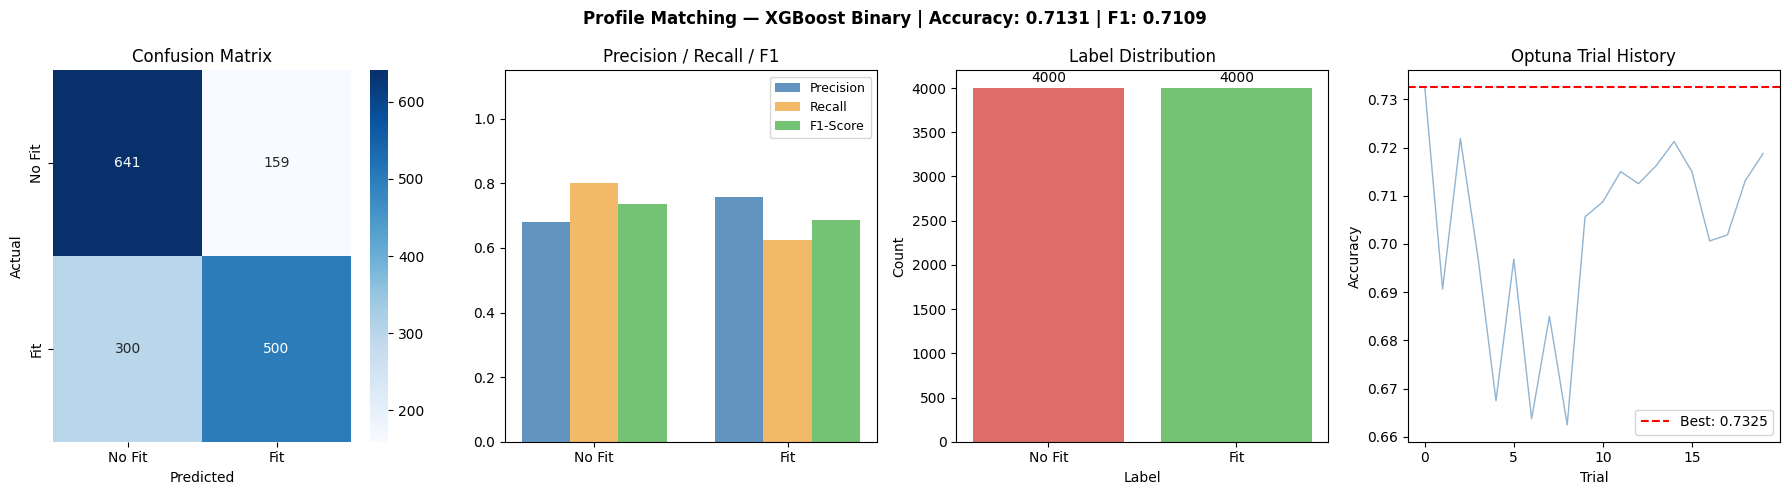

In [ ]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig)

ax1 = fig.add_subplot(gs[0])
sns.heatmap(confusion_matrix(y_te_match, y_pred_match), annot=True, fmt="d",
            cmap="Blues", ax=ax1,
            xticklabels=["No Fit", "Fit"],
            yticklabels=["No Fit", "Fit"])
ax1.set_title("Confusion Matrix")
ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")

ax2 = fig.add_subplot(gs[1])
classes     = ["No Fit", "Fit"]
prec_scores = [report_match[c]["precision"] for c in classes]
rec_scores  = [report_match[c]["recall"]    for c in classes]
f1_scores   = [report_match[c]["f1-score"]  for c in classes]
x = np.arange(len(classes)); w = 0.25
ax2.bar(x - w, prec_scores, w, label="Precision", color="steelblue", alpha=0.85)
ax2.bar(x,     rec_scores,  w, label="Recall",    color="#f0ad4e",   alpha=0.85)
ax2.bar(x + w, f1_scores,   w, label="F1-Score",  color="#5cb85c",   alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(classes, fontsize=10)
ax2.set_title("Precision / Recall / F1")
ax2.set_ylim(0, 1.15); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[2])
lc = pd.Series(y_match).value_counts().sort_index()
ax3.bar(["No Fit", "Fit"], lc.values,
        color=["#d9534f", "#5cb85c"], alpha=0.85)
ax3.set_title("Label Distribution")
ax3.set_xlabel("Label"); ax3.set_ylabel("Count")
for bar, val in zip(ax3.patches, lc.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30, str(val),
             ha="center", va="bottom", fontsize=10)

ax4 = fig.add_subplot(gs[3])
trial_vals = [t.value for t in study_match.trials]
ax4.plot(trial_vals, color="steelblue", alpha=0.6, linewidth=1)
ax4.axhline(study_match.best_value, color="red", linestyle="--",
            label=f"Best: {study_match.best_value:.4f}")
ax4.set_title("Optuna Trial History")
ax4.set_xlabel("Trial"); ax4.set_ylabel("Accuracy"); ax4.legend()

plt.suptitle(
    f"Profile Matching — XGBoost Binary | Accuracy: {acc_match:.4f} | "
    f"F1: {report_match['weighted avg']['f1-score']:.4f}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(MODEL_DIR / "match_xgb_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. ATS Scoring — XGBoost Regressor

In [ ]:
def ats_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 300),
        "max_depth":        trial.suggest_int("max_depth", 3, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "use_label_encoder": False,
        "eval_metric": "mlogloss",
        "random_state": SEED,
        "device": "cpu",
        "nthread": -1,
    }
    model = XGBClassifier(**params)
    model.fit(X_tr_ats_bal, y_tr_ats_bal)
    return accuracy_score(y_te_ats, model.predict(X_te_ats))

study_ats = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_ats.optimize(ats_objective, n_trials=CFG.optuna_trials)

best_ats_params = study_ats.best_params
best_ats_params.update({
    "use_label_encoder": False, "eval_metric": "mlogloss",
    "random_state": SEED, "device": "cpu", "nthread": -1,
})

ats_model = XGBClassifier(**best_ats_params)
ats_model.fit(X_tr_ats_bal, y_tr_ats_bal)

y_pred_ats  = ats_model.predict(X_te_ats)
acc_ats     = accuracy_score(y_te_ats, y_pred_ats)
report_ats  = classification_report(
    y_te_ats, y_pred_ats,
    target_names=["Low ATS", "Medium ATS", "High ATS"],
    output_dict=True
)

sep = "=" * 58
print(sep)
print("  ATS SCORING — XGBoost Classifier")
print(sep)
print(f"  Train size  : {len(X_tr_ats_bal)} (after SMOTE)")
print(f"  Test size   : {len(X_te_ats)}")
print(f"  Features    : {X_te_ats.shape[1]} (rule-based)")
print(f"  Best params : {best_ats_params}")
print(sep)
print(f"  Accuracy    : {acc_ats:.4f}")
print(f"  Macro F1    : {report_ats['macro avg']['f1-score']:.4f}")
print(f"  Macro Prec  : {report_ats['macro avg']['precision']:.4f}")
print(f"  Macro Recall: {report_ats['macro avg']['recall']:.4f}")
print(f"  Weighted F1 : {report_ats['weighted avg']['f1-score']:.4f}")
print(sep)
rows_ats = []
for label in ["Low ATS", "Medium ATS", "High ATS"]:
    r = report_ats[label]
    rows_ats.append([label, f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                     f"{r['f1-score']:.4f}", int(r['support'])])
print(tabulate(rows_ats,
               headers=["Class", "Precision", "Recall", "F1-Score", "Support"],
               tablefmt="rounded_outline"))

joblib.dump(ats_model,         MODEL_DIR / "ats_scorer_xgb.pkl")
joblib.dump(ATS_LABEL_MAP,     MODEL_DIR / "ats_label_map.pkl")
joblib.dump(feature_names_ats, MODEL_DIR / "ats_feature_names.pkl")
print("\nSaved: ats_scorer_xgb.pkl")

  ATS SCORING — XGBoost Classifier
  Train size  : 6156 (after SMOTE)
  Test size   : 1020
  Features    : 16 (rule-based)
  Best params : {'n_estimators': 175, 'max_depth': 6, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42, 'device': 'cpu', 'nthread': -1}
  Accuracy    : 0.4627
  Macro F1    : 0.4262
  Macro Prec  : 0.4266
  Macro Recall: 0.4277
  Weighted F1 : 0.4687
╭────────────┬─────────────┬──────────┬────────────┬───────────╮
│ Class      │   Precision │   Recall │   F1-Score │   Support │
├────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Low ATS    │      0.6237 │   0.5653 │     0.593  │       513 │
│ Medium ATS │      0.3478 │   0.3765 │     0.3616 │       255 │
│ High ATS   │      0.3082 │   0.3413 │     0.3239 │       252 │
╰────────────┴─────────────┴──────────┴────────────┴───────────╯

Saved: ats_scorer_xgb.pkl


## 13. ATS Scoring — Visualization

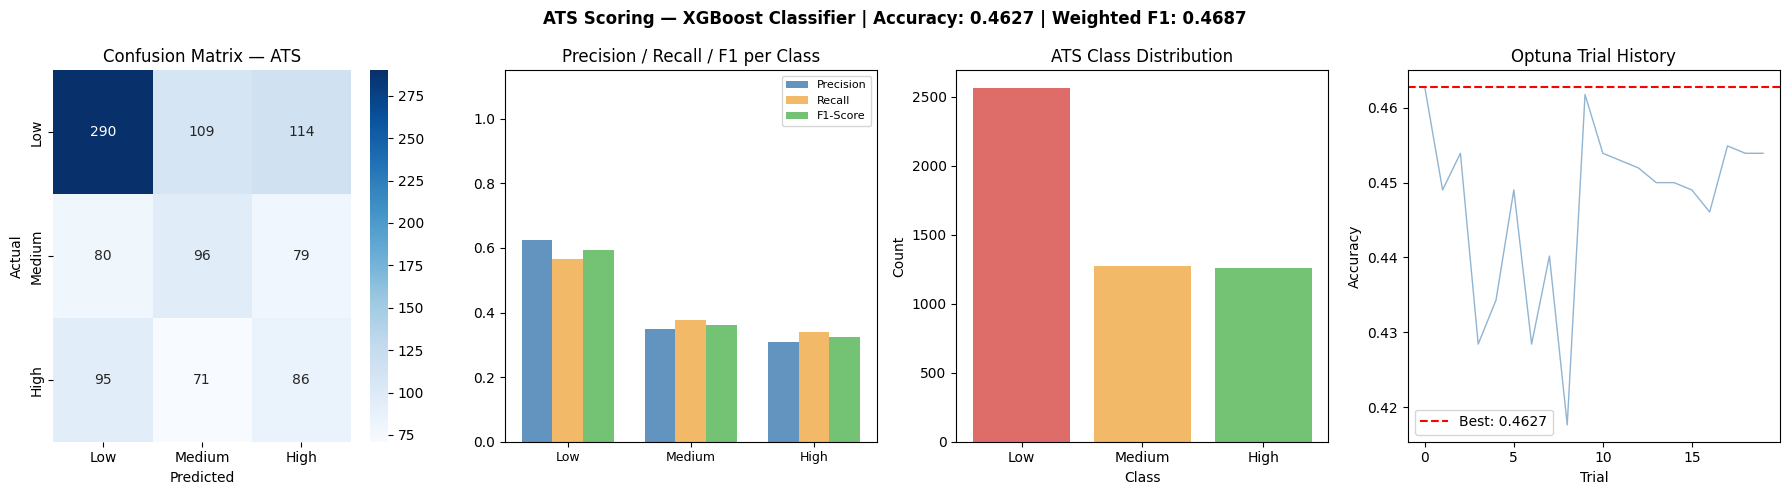

In [ ]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig)

ax1 = fig.add_subplot(gs[0])
sns.heatmap(confusion_matrix(y_te_ats, y_pred_ats), annot=True, fmt="d",
            cmap="Blues", ax=ax1,
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
ax1.set_title("Confusion Matrix — ATS")
ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")

ax2 = fig.add_subplot(gs[1])
classes_ats = ["Low ATS", "Medium ATS", "High ATS"]
prec_ats    = [report_ats[c]["precision"] for c in classes_ats]
rec_ats     = [report_ats[c]["recall"]    for c in classes_ats]
f1_ats      = [report_ats[c]["f1-score"]  for c in classes_ats]
x = np.arange(len(classes_ats)); w = 0.25
ax2.bar(x - w, prec_ats, w, label="Precision", color="steelblue", alpha=0.85)
ax2.bar(x,     rec_ats,  w, label="Recall",    color="#f0ad4e",   alpha=0.85)
ax2.bar(x + w, f1_ats,   w, label="F1-Score",  color="#5cb85c",   alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(["Low", "Medium", "High"], fontsize=9)
ax2.set_title("Precision / Recall / F1 per Class")
ax2.set_ylim(0, 1.15); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[2])
class_counts = pd.Series(y_ats).value_counts().sort_index()
ax3.bar(["Low", "Medium", "High"], class_counts.values,
        color=["#d9534f", "#f0ad4e", "#5cb85c"], alpha=0.85)
ax3.set_title("ATS Class Distribution")
ax3.set_xlabel("Class"); ax3.set_ylabel("Count")

ax4 = fig.add_subplot(gs[3])
trial_vals = [t.value for t in study_ats.trials]
ax4.plot(trial_vals, color="steelblue", alpha=0.6, linewidth=1)
ax4.axhline(study_ats.best_value, color="red", linestyle="--",
            label=f"Best: {study_ats.best_value:.4f}")
ax4.set_title("Optuna Trial History")
ax4.set_xlabel("Trial"); ax4.set_ylabel("Accuracy"); ax4.legend()

plt.suptitle(
    f"ATS Scoring — XGBoost Classifier | Accuracy: {acc_ats:.4f} | "
    f"Weighted F1: {report_ats['weighted avg']['f1-score']:.4f}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(MODEL_DIR / "ats_xgb_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Section Scoring — XGBoost Multi-output Regressor

In [ ]:
def section_objective(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 100, 300),
        "max_depth":       trial.suggest_int("max_depth", 3, 6),
        "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":       trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": SEED,
        "device": "cpu",
        "nthread": -1,
    }
    model = MultiOutputRegressor(XGBRegressor(**params), n_jobs=-1)
    model.fit(X_tr_sec, y_tr_sec)
    preds = model.predict(X_te_sec)
    maes  = [mean_absolute_error(y_te_sec[:, i], preds[:, i])
             for i in range(y_te_sec.shape[1])]
    return -np.mean(maes)

study_section = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_section.optimize(section_objective, n_trials=CFG.optuna_trials)

best_sec_params = study_section.best_params
best_sec_params.update({"random_state": SEED, "device": "cpu", "nthread": -1})

section_model = MultiOutputRegressor(XGBRegressor(**best_sec_params), n_jobs=-1)
section_model.fit(X_tr_sec, y_tr_sec)

y_pred_sec      = section_model.predict(X_te_sec)
section_metrics = {}
rows = []
for i, col in enumerate(TARGET_COLS):
    mae  = mean_absolute_error(y_te_sec[:, i], y_pred_sec[:, i])
    rmse = np.sqrt(mean_squared_error(y_te_sec[:, i], y_pred_sec[:, i]))
    r2   = r2_score(y_te_sec[:, i], y_pred_sec[:, i])
    mape = float(np.mean(np.abs(
        (y_te_sec[:, i] - y_pred_sec[:, i]) / np.clip(np.abs(y_te_sec[:, i]), 1e-8, None)
    )) * 100)
    section_metrics[col] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}
    rows.append([col.replace("score_", "").capitalize(),
                 f"{mae:.4f}", f"{rmse:.4f}", f"{r2:.4f}", f"{mape:.2f}%"])

sep = "=" * 58
print(sep)
print("  SECTION SCORING — XGBoost Multi-output Regressor")
print(sep)
print(f"  Train size  : {len(X_tr_sec)}")
print(f"  Test size   : {len(X_te_sec)}")
print(f"  Features    : {X_te_sec.shape[1]} (after PCA)")
print(f"  Best params : {best_sec_params}")
print(sep)
print(tabulate(rows,
               headers=["Section", "MAE", "RMSE", "R²", "MAPE"],
               tablefmt="rounded_outline"))

joblib.dump(section_model, MODEL_DIR / "section_scorer_xgb.pkl")
joblib.dump(TARGET_COLS,   MODEL_DIR / "section_target_cols.pkl")
print("\nSaved: section_scorer_xgb.pkl")

  SECTION SCORING — XGBoost Multi-output Regressor
  Train size  : 6400
  Test size   : 1600
  Features    : 138 (after PCA)
  Best params : {'n_estimators': 294, 'max_depth': 5, 'learning_rate': 0.07071005741224382, 'subsample': 0.6975499843454273, 'colsample_bytree': 0.9000332103913908, 'random_state': 42, 'device': 'cpu', 'nthread': -1}
╭────────────┬────────┬────────┬────────┬─────────────╮
│ Section    │    MAE │   RMSE │     R² │ MAPE        │
├────────────┼────────┼────────┼────────┼─────────────┤
│ Experience │ 0.0538 │ 0.0691 │ 0.702  │ 1283596.12% │
│ Skills     │ 0.047  │ 0.0607 │ 0.6993 │ 7.94%       │
│ Education  │ 0.0627 │ 0.0805 │ 0.6065 │ 13.94%      │
│ Overall    │ 0.0084 │ 0.012  │ 0.9918 │ 1416162.00% │
╰────────────┴────────┴────────┴────────┴─────────────╯

Saved: section_scorer_xgb.pkl


## 15. Section Scoring — Visualization

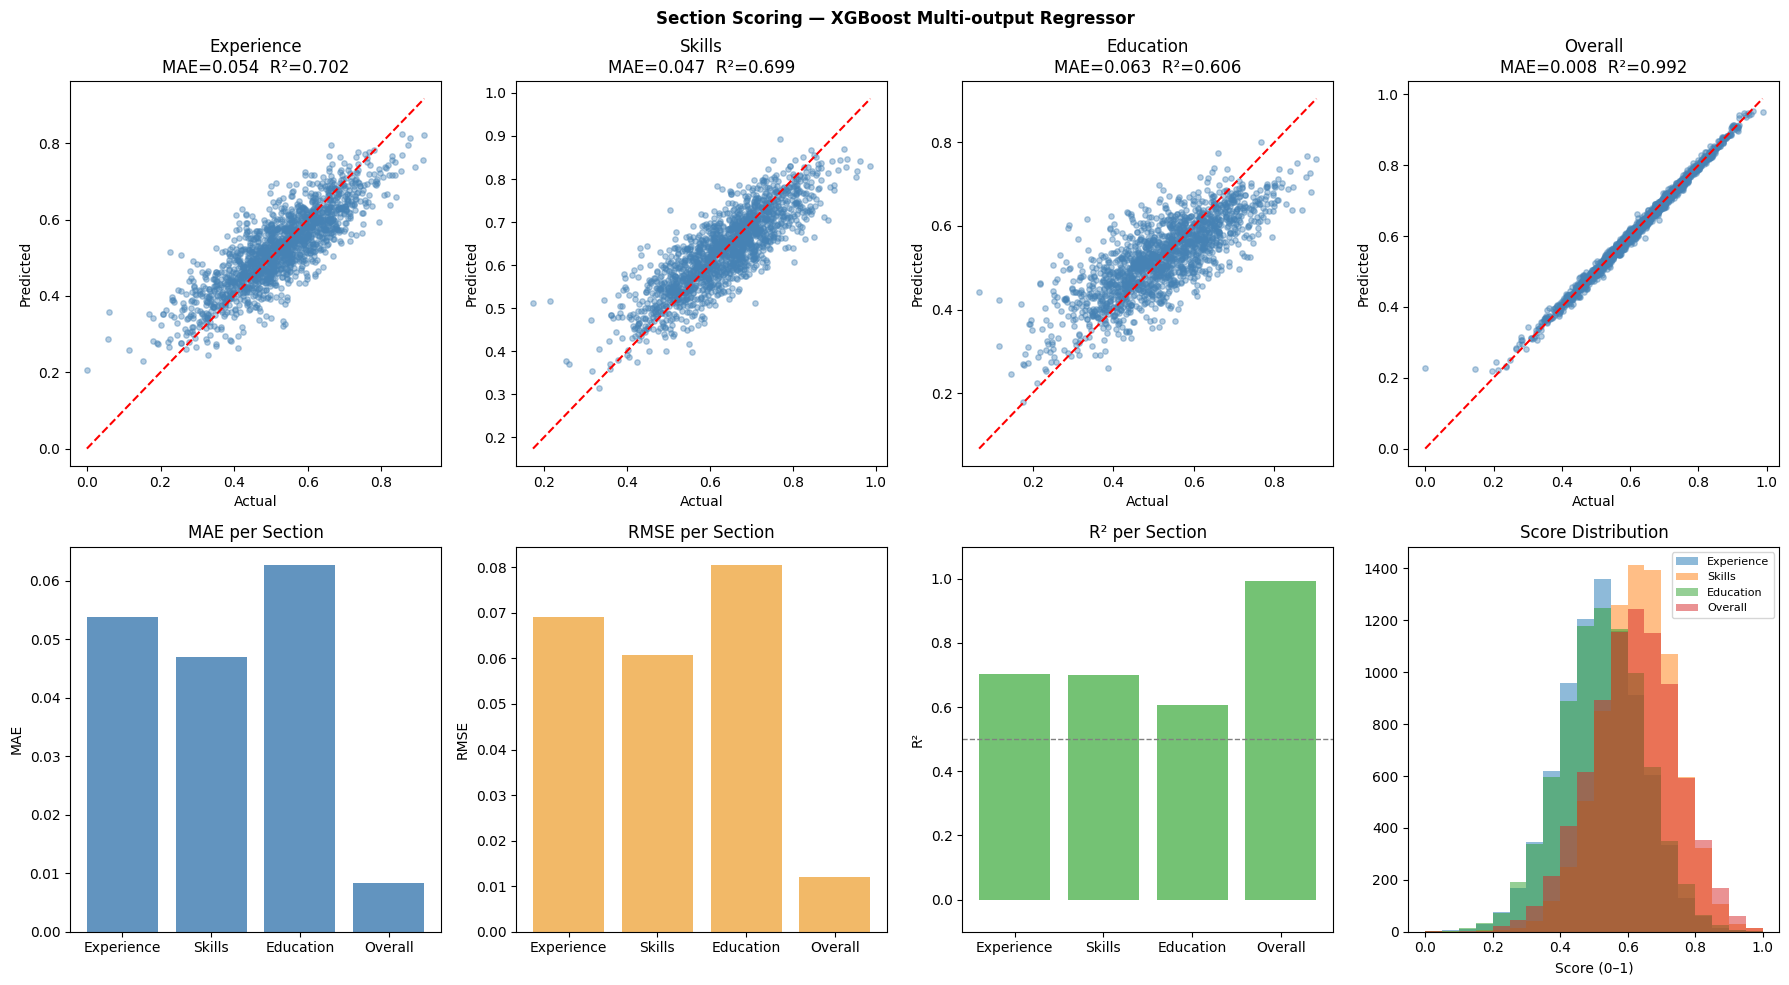

In [ ]:
section_labels = [c.replace("score_", "").capitalize() for c in TARGET_COLS]
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig)

for i, (col, label) in enumerate(zip(TARGET_COLS, section_labels)):
    ax = fig.add_subplot(gs[0, i])
    ax.scatter(y_te_sec[:, i], y_pred_sec[:, i], alpha=0.4, s=15, color="steelblue")
    mn = min(y_te_sec[:, i].min(), y_pred_sec[:, i].min())
    mx = max(y_te_sec[:, i].max(), y_pred_sec[:, i].max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5)
    m = section_metrics[col]
    ax.set_title(f"{label}\nMAE={m['MAE']:.3f}  R²={m['R2']:.3f}")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")

ax5 = fig.add_subplot(gs[1, 0])
ax5.bar(section_labels, [section_metrics[c]["MAE"] for c in TARGET_COLS],
        color="steelblue", alpha=0.85)
ax5.set_title("MAE per Section"); ax5.set_ylabel("MAE")

ax6 = fig.add_subplot(gs[1, 1])
ax6.bar(section_labels, [section_metrics[c]["RMSE"] for c in TARGET_COLS],
        color="#f0ad4e", alpha=0.85)
ax6.set_title("RMSE per Section"); ax6.set_ylabel("RMSE")

ax7 = fig.add_subplot(gs[1, 2])
r2s = [section_metrics[c]["R2"] for c in TARGET_COLS]
ax7.bar(section_labels, r2s,
        color=["#5cb85c" if v >= 0.5 else "#d9534f" for v in r2s], alpha=0.85)
ax7.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax7.set_title("R² per Section"); ax7.set_ylabel("R²"); ax7.set_ylim(-0.1, 1.1)

ax8 = fig.add_subplot(gs[1, 3])
for i, (col, label) in enumerate(zip(TARGET_COLS, section_labels)):
    ax8.hist(y_section[:, i], bins=20, alpha=0.5, label=label)
ax8.set_title("Score Distribution")
ax8.set_xlabel("Score (0–1)"); ax8.legend(fontsize=8)

plt.suptitle("Section Scoring — XGBoost Multi-output Regressor",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "section_xgb_results.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 16. Full Metrics Summary

  TRAINING SUMMARY — XGBoost Model
  Embedding      : nomic-ai/nomic-embed-text-v1 (zero-shot)
  PCA components : 128
  Split          : train_test_split 80/20 | seed=42
  Tuning         : Optuna (20 trials per model)
╭──────────────────┬──────────────────────────────┬────────────┬──────────────────────────────────────╮
│ Task             │ Algorithm                    │ Primary    │ Other Metrics                        │
├──────────────────┼──────────────────────────────┼────────────┼──────────────────────────────────────┤
│ Profile Matching │ XGBoost Classifier (Binary)  │ Acc=0.7131 │ F1=0.7109 | Prec=0.7200 | Rec=0.7131 │
│ ATS Scoring      │ XGBoost Classifier (3-class) │ Acc=0.4627 │ F1=0.4687 | Prec=0.4266 | Rec=0.4277 │
│ Section Scoring  │ XGBoost Multi-output         │ MAE=0.0084 │ RMSE=0.0120 | R²=0.9918              │
╰──────────────────┴──────────────────────────────┴────────────┴──────────────────────────────────────╯

  Per-class metrics — Profile Matching
╭─────────┬───

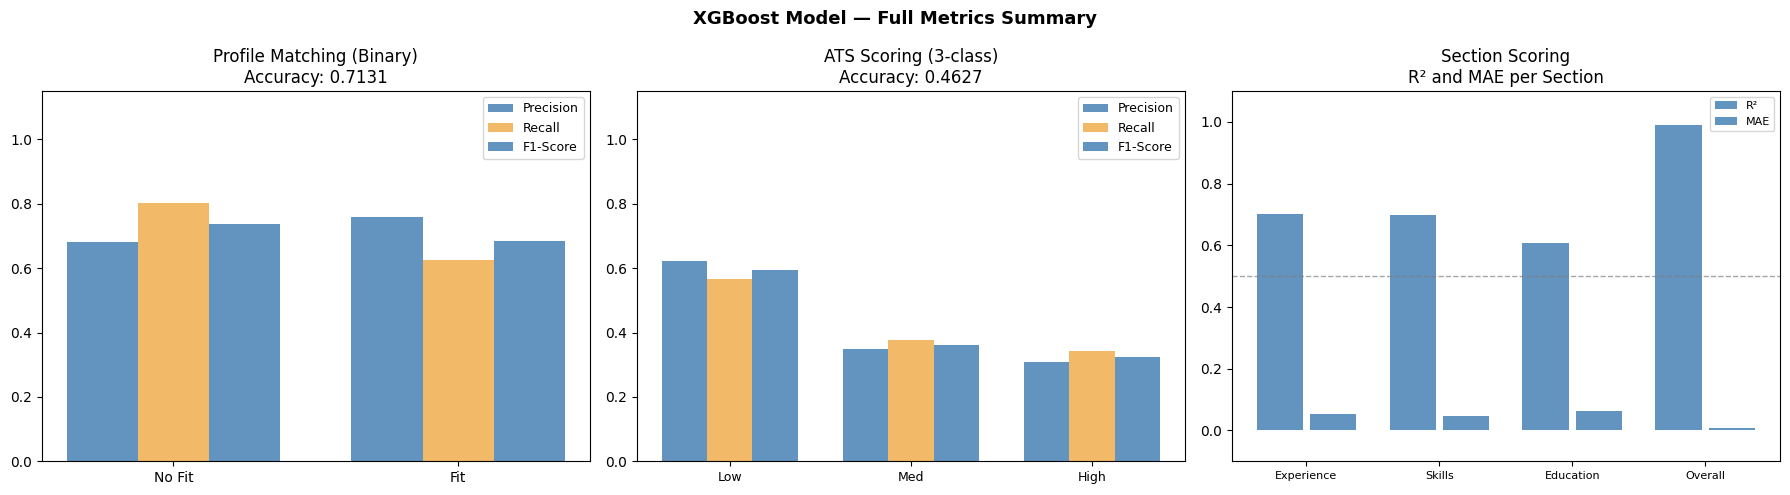

Saved: xgb_summary.png


In [ ]:
sep = "=" * 70
print(sep)
print("  TRAINING SUMMARY — XGBoost Model")
print(sep)
print(f"  Embedding      : nomic-ai/nomic-embed-text-v1 (zero-shot)")
print(f"  PCA components : {CFG.pca_components}")
print(f"  Split          : train_test_split 80/20 | seed={SEED}")
print(f"  Tuning         : Optuna ({CFG.optuna_trials} trials per model)")
print(sep)

summary_rows = [
    ["Profile Matching", "XGBoost Classifier (Binary)",
     f"Acc={acc_match:.4f}",
     f"F1={report_match['weighted avg']['f1-score']:.4f} | "
     f"Prec={report_match['macro avg']['precision']:.4f} | "
     f"Rec={report_match['macro avg']['recall']:.4f}"],
    ["ATS Scoring", "XGBoost Classifier (3-class)",
     f"Acc={acc_ats:.4f}",
     f"F1={report_ats['weighted avg']['f1-score']:.4f} | "
     f"Prec={report_ats['macro avg']['precision']:.4f} | "
     f"Rec={report_ats['macro avg']['recall']:.4f}"],
    ["Section Scoring", "XGBoost Multi-output",
     f"MAE={section_metrics['score_overall']['MAE']:.4f}",
     f"RMSE={section_metrics['score_overall']['RMSE']:.4f} | "
     f"R²={section_metrics['score_overall']['R2']:.4f}"],
]
print(tabulate(summary_rows,
               headers=["Task", "Algorithm", "Primary", "Other Metrics"],
               tablefmt="rounded_outline"))

print()
print("  Per-class metrics — Profile Matching")
print(tabulate(rows_cls,
               headers=["Class", "Precision", "Recall", "F1-Score", "Support"],
               tablefmt="rounded_outline"))

print()
print("  Per-class metrics — ATS Scoring")
print(tabulate(rows_ats,
               headers=["Class", "Precision", "Recall", "F1-Score", "Support"],
               tablefmt="rounded_outline"))

print()
print("  Per-section metrics — Section Scoring")
print(tabulate(rows,
               headers=["Section", "MAE", "RMSE", "R²", "MAPE"],
               tablefmt="rounded_outline"))

print()
print("  Saved model files:")
file_rows = []
for f in sorted(MODEL_DIR.glob("*.pkl")):
    file_rows.append([f.name, f"{f.stat().st_size / 1024:.1f} KB"])
print(tabulate(file_rows, headers=["File", "Size"], tablefmt="rounded_outline"))
print(sep)

section_labels = [c.replace("score_", "").capitalize() for c in TARGET_COLS]
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])
classes     = ["No Fit", "Fit"]
prec_scores = [report_match[c]["precision"] for c in classes]
rec_scores  = [report_match[c]["recall"]    for c in classes]
f1_scores   = [report_match[c]["f1-score"]  for c in classes]
x = np.arange(len(classes)); w = 0.25
ax1.bar(x - w, prec_scores, w, label="Precision", color="steelblue", alpha=0.85)
ax1.bar(x,     rec_scores,  w, label="Recall",    color="#f0ad4e",   alpha=0.85)
ax1.bar(x + w, f1_scores,   w, label="F1-Score",  color="steelblue",   alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(classes, fontsize=10)
ax1.set_title(f"Profile Matching (Binary)\nAccuracy: {acc_match:.4f}")
ax1.set_ylim(0, 1.15); ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[1])
classes_ats = ["Low ATS", "Medium ATS", "High ATS"]
prec_ats    = [report_ats[c]["precision"] for c in classes_ats]
rec_ats     = [report_ats[c]["recall"]    for c in classes_ats]
f1_ats      = [report_ats[c]["f1-score"]  for c in classes_ats]
x2 = np.arange(len(classes_ats))
ax2.bar(x2 - w, prec_ats, w, label="Precision", color="steelblue", alpha=0.85)
ax2.bar(x2,     rec_ats,  w, label="Recall",    color="#f0ad4e",   alpha=0.85)
ax2.bar(x2 + w, f1_ats,   w, label="F1-Score",  color="steelblue",   alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(["Low", "Med", "High"], fontsize=9)
ax2.set_title(f"ATS Scoring (3-class)\nAccuracy: {acc_ats:.4f}")
ax2.set_ylim(0, 1.15); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[2])
r2s      = [section_metrics[c]["R2"]  for c in TARGET_COLS]
mae_vals = [section_metrics[c]["MAE"] for c in TARGET_COLS]
x3 = np.arange(len(section_labels))
ax3.bar(x3 - 0.2, r2s,      0.35, label="R²",  color="steelblue",   alpha=0.85)
ax3.bar(x3 + 0.2, mae_vals,  0.35, label="MAE", color="steelblue", alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(section_labels, fontsize=8)
ax3.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax3.set_title("Section Scoring\nR² and MAE per Section")
ax3.set_ylim(-0.1, 1.1); ax3.legend(fontsize=8)

plt.suptitle("XGBoost Model — Full Metrics Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "xgb_summary.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: xgb_summary.png")

## 17. Inference Helper

In [ ]:
def grade_score(score: float) -> str:
    if score >= CFG.grade_excellent: return "excellent"
    if score >= CFG.grade_good:      return "good"
    if score >= CFG.grade_fair:      return "fair"
    return "bad"

def predict_match(cv_text: str, profile_text: str) -> dict:
    emb_cv  = encoder.encode([f"search_document: {cv_text}"],  normalize_embeddings=True)[0]
    emb_job = encoder.encode([f"search_query: {profile_text}"], normalize_embeddings=True)[0]
    explicit = extract_explicit_features(cv_text, profile_text)
    raw      = np.hstack([[np.dot(emb_cv, emb_job)],
                           np.abs(emb_cv - emb_job),
                           emb_cv * emb_job])
    feat     = np.hstack([pca_match.transform(raw.reshape(1, -1))[0], explicit]).reshape(1, -1)
    proba    = match_model.predict_proba(feat)[0]
    pred     = int(proba.argmax())
    if proba.max() < CFG.match_confidence_threshold:
        pred = 0
    label_map = {0: "No Fit", 1: "Fit"}
    return {
        "match_label":      label_map[pred],
        "match_confidence": round(float(proba.max()), 4),
        "match_score":      round(float(np.dot(emb_cv, emb_job)), 4),
    }

def predict_ats(cv_text: str) -> dict:
    feats     = extract_ats_features(cv_text)
    x         = np.array([feats[n] for n in feature_names_ats]).reshape(1, -1)
    pred      = int(ats_model.predict(x)[0])
    proba     = ats_model.predict_proba(x)[0]
    label_map = {0: "Low ATS", 1: "Medium ATS", 2: "High ATS"}
    return {
        "ats_label":      label_map[pred],
        "ats_confidence": round(float(proba.max()), 4),
    }

def predict_sections(cv_text: str, profile_text: str) -> dict:
    emb_cv   = encoder.encode([f"search_document: {cv_text}"],  normalize_embeddings=True)[0]
    emb_job  = encoder.encode([f"search_query: {profile_text}"], normalize_embeddings=True)[0]
    explicit = extract_explicit_features(cv_text, profile_text)
    raw      = np.hstack([[np.dot(emb_cv, emb_job)],
                           np.abs(emb_cv - emb_job),
                           emb_cv * emb_job])
    feat     = np.hstack([pca_section.transform(raw.reshape(1, -1))[0], explicit]).reshape(1, -1)
    preds    = section_model.predict(feat)[0]
    return {
        col.replace("score_", ""): round(float(np.clip(p, 0, 1)) * 100, 1)
        for col, p in zip(TARGET_COLS, preds)
    }

def run_full_analysis(cv_text: str, profile_text: str) -> dict:
    match_res   = predict_match(cv_text, profile_text)
    ats_res     = predict_ats(cv_text)
    section_res = predict_sections(cv_text, profile_text)
    ats_score   = (100 if ats_res["ats_label"] == "High ATS" else
                   50  if ats_res["ats_label"] == "Medium ATS" else 20)
    overall     = round(
        section_res["overall"] * CFG.weight_section_overall +
        ats_score * CFG.weight_ats, 1
    )
    return {
        "overall_score":  overall,
        "grade":          grade_score(overall),
        "match":          match_res,
        "ats":            ats_res,
        "section_scores": section_res,
    }

TEST_CV = (
    "John Doe | john@email.com | +1-555-123-4567\n"
    "Summary: Software engineer with 5 years experience in Python, FastAPI, and React.\n"
    "Skills: Python, FastAPI, React, PostgreSQL, Docker, Git\n"
    "Experience: Backend Engineer at TechCorp 2020-2024. Built REST APIs serving 50k users.\n"
    "  Reduced latency by 30% through caching optimization.\n"
    "Education: B.Sc Computer Science, MIT, 2020"
)
TEST_PROFILE = (
    "Looking for a backend engineer with Python and FastAPI experience. "
    "Must know REST API design, databases, and cloud deployment."
)
result = run_full_analysis(TEST_CV, TEST_PROFILE)
print(json.dumps(result, indent=2))

{
  "overall_score": 60.1,
  "grade": "good",
  "match": {
    "match_label": "Fit",
    "match_confidence": 0.7388,
    "match_score": 0.754
  },
  "ats": {
    "ats_label": "Low ATS",
    "ats_confidence": 0.7473
  },
  "section_scores": {
    "experience": 74.7,
    "skills": 83.0,
    "education": 62.6,
    "overall": 86.9
  }
}


## 18. Download Models

In [ ]:
import shutil
from google.colab import files

zip_path = "cv_analysis_xgb_models.zip"
shutil.make_archive("cv_analysis_xgb_models", "zip", MODEL_DIR)
size_mb  = Path(zip_path).stat().st_size / (1024 * 1024)
print(f"Archive: {zip_path}  ({size_mb:.1f} MB)")
files.download(zip_path)

Archive: cv_analysis_xgb_models.zip  (2.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>